In [2]:
import pandas as pd
import glob
import os

In [3]:
files = glob.glob("*.csv")
all_data = []
for file in files:
    df = pd.read_csv(file)
    provinsi = (os.path.basename(file).replace('jumlah_penduduk_', '').replace('.csv', '').replace('_', ' ').title())

    df['provinsi'] = provinsi
    all_data.append(df)

df_gabungan = pd.concat(all_data, ignore_index=True)

df_gabungan = df_gabungan[
    ['provinsi', 'laki_laki', 'perempuan', 'total_keseluruhan']
]

display(df_gabungan)

,provinsi,laki_laki,perempuan,total_keseluruhan
0,Data Penduduk Indonesia,2825512,2800448,5625960
1,Data Penduduk Indonesia,795200,755600,1550800
2,Data Penduduk Indonesia,2234600,2226700,4461300
3,Data Penduduk Indonesia,6369700,6167700,12537400
4,Data Penduduk Indonesia,1091256,1046788,2138044
5,Data Penduduk Indonesia,5360827,5317148,10677975
6,Data Penduduk Indonesia,626100,616200,1242300
7,Data Penduduk Indonesia,1914250,1854230,3768480
8,Data Penduduk Indonesia,25682100,25076900,50759000
9,Data Penduduk Indonesia,19203434,19030499,38233933


In [6]:
df_gabungan.to_csv('data_penduduk_indonesia.csv', index=False)

### EXPLORATORY DATA ANALYSIS

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data_olah = pd.read_csv('data_penduduk_indonesia.csv')
display(data_olah)

,provinsi,laki_laki,perempuan,total_keseluruhan
0,Aceh,2825512,2800448,5625960
1,Babel,795200,755600,1550800
2,Bali,2234600,2226700,4461300
3,Banten,6369700,6167700,12537400
4,Bengkulu,1091256,1046788,2138044
5,Dki Jakarta,5360827,5317148,10677975
6,Gorontalo,626100,616200,1242300
7,Jambi,1914250,1854230,3768480
8,Jawa Barat,25682100,25076900,50759000
9,Jawa Tengah,19203434,19030499,38233933


In [6]:
print(data_olah.info())
print(data_olah.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   provinsi           38 non-null     object
 1   laki_laki          38 non-null     int64 
 2   perempuan          38 non-null     int64 
 3   total_keseluruhan  38 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.3+ KB
None
provinsi             0
laki_laki            0
perempuan            0
total_keseluruhan    0
dtype: int64


In [7]:
print(data_olah.describe())

          laki_laki     perempuan  total_keseluruhan
count  3.800000e+01  3.800000e+01       3.800000e+01
mean   3.767515e+06  3.703195e+06       7.470710e+06
std    5.736803e+06  5.683921e+06       1.142027e+07
min    2.850300e+05  2.646100e+05       5.496400e+05
25%    7.939175e+05  7.534250e+05       1.531750e+06
50%    1.892175e+06  1.867504e+06       3.774990e+06
75%    3.352457e+06  3.234486e+06       6.586944e+06
max    2.568210e+07  2.507690e+07       5.075900e+07


In [8]:
total = data_olah["total_keseluruhan"].sum()
print(f"Total Penduduk Indonesia: {total: }")

Total Penduduk Indonesia:  283886990


Total Laki-laki: 143165562
Total Perempuan: 140721428


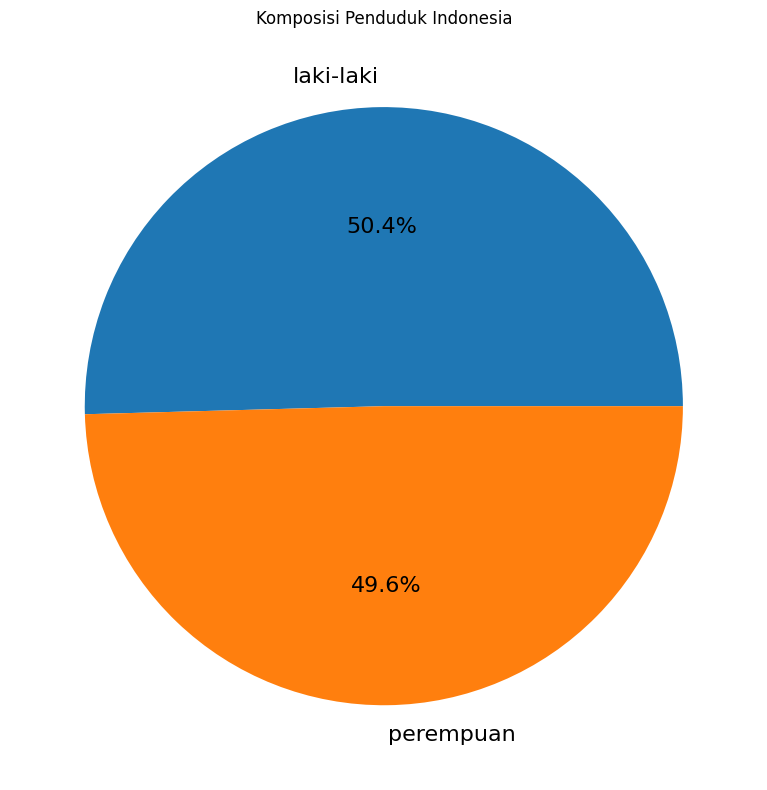

In [9]:
total_laki = data_olah["laki_laki"].sum()
total_perempuan = data_olah["perempuan"].sum()

print("Total Laki-laki:", total_laki)
print("Total Perempuan:", total_perempuan)

plt.figure(figsize=(10,8))
plt.pie(
    [total_laki, total_perempuan],
    labels=['laki-laki', 'perempuan'],
    autopct='%1.1f%%',
    textprops={'fontsize': 16}
)

plt.title('Komposisi Penduduk Indonesia')
plt.tight_layout()
plt.show()

,provinsi,laki_laki,perempuan,total_keseluruhan
8,Jawa Barat,25682100,25076900,50759000
10,Jawa Timur,20978500,21110800,42089300
9,Jawa Tengah,19203434,19030499,38233933
36,Sumatera Utara,7862993,7922846,15785839
3,Banten,6369700,6167700,12537400


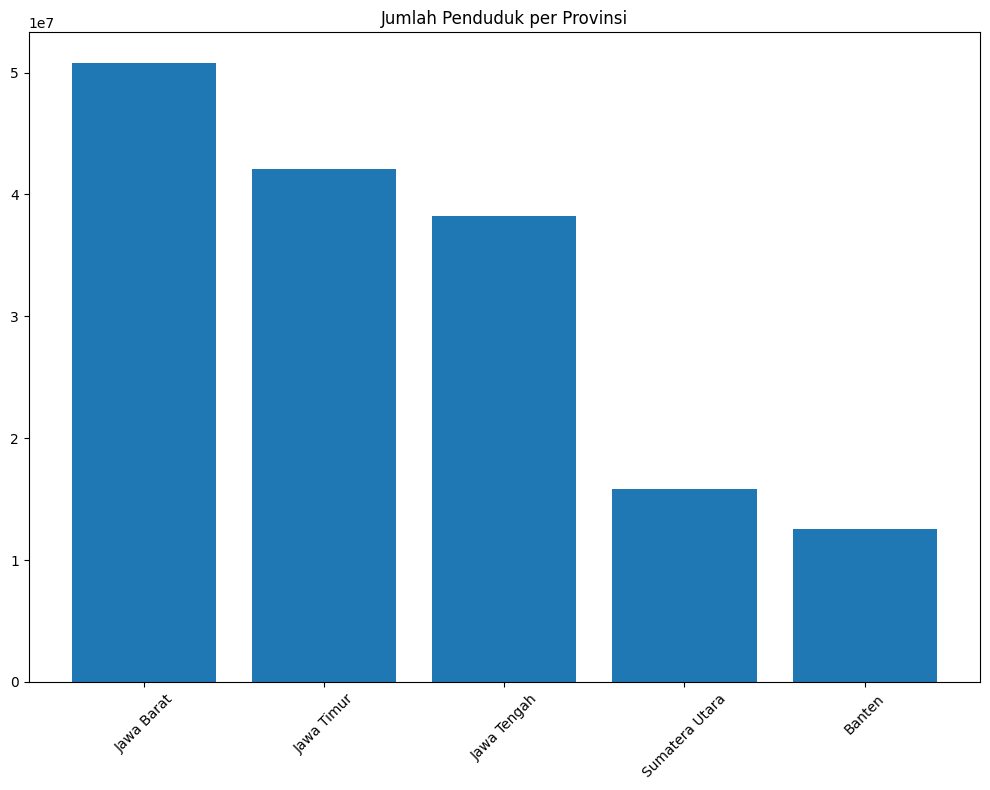

In [10]:
prov_terbesar = data_olah.sort_values(
    by = 'total_keseluruhan',
    ascending=False
)
top5=  prov_terbesar.head(5)
display(top5)

plt.figure(figsize=(10,8))
plt.bar(top5['provinsi'], top5['total_keseluruhan'])
plt.xticks(rotation=45)
plt.title('Jumlah Penduduk per Provinsi')
plt.tight_layout()
plt.show()

,provinsi,laki_laki,perempuan,total_keseluruhan
26,Papua Selatan,285030,264610,549640
23,Papua Barat,308424,279221,587645
24,Papua Barat Daya,331210,305230,636440
15,Kalimantan Utara,389219,356237,745456
22,Papua,560900,512700,1073600


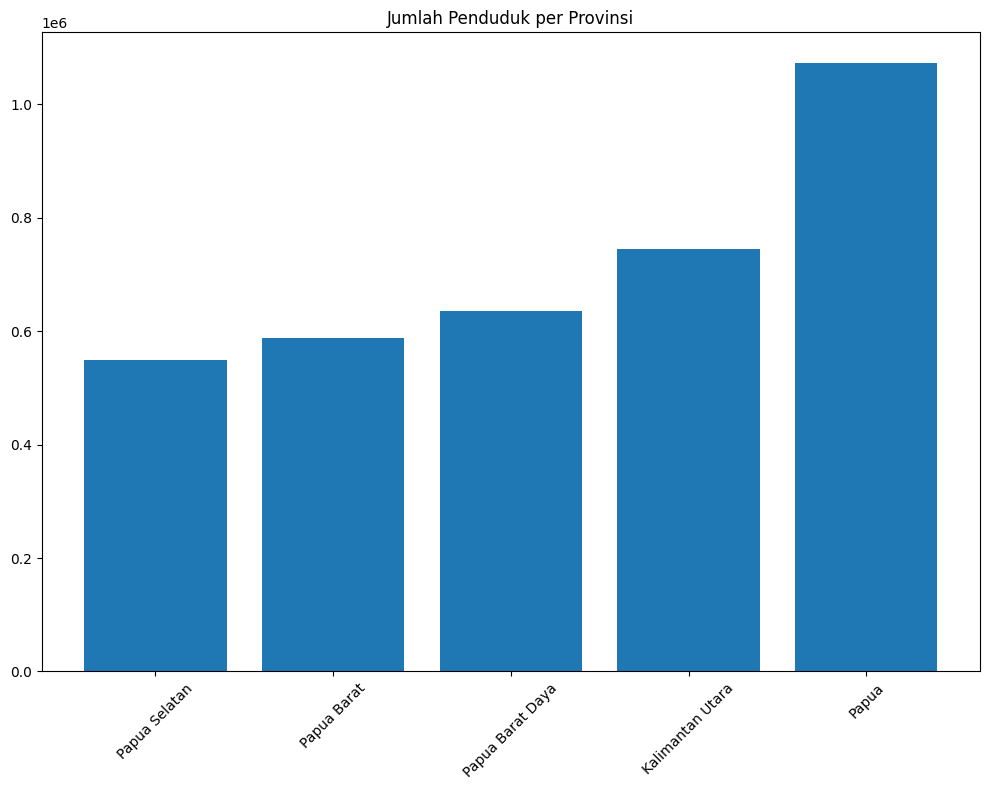

In [11]:
prov_terkecil = data_olah.sort_values(
    by = 'total_keseluruhan',
    ascending=True
)
kecil5= prov_terkecil.head(5)
display(kecil5)

plt.figure(figsize=(10,8))
plt.bar(kecil5['provinsi'], kecil5['total_keseluruhan'])
plt.xticks(rotation=45)
plt.title('Jumlah Penduduk per Provinsi')
plt.tight_layout()
plt.show()

,provinsi,laki_laki,perempuan,total_keseluruhan,Sex_ratio
0,Aceh,2825512,2800448,5625960,99.112940
1,Babel,795200,755600,1550800,95.020121
2,Bali,2234600,2226700,4461300,99.646469
3,Banten,6369700,6167700,12537400,96.828736
4,Bengkulu,1091256,1046788,2138044,95.925062
5,Dki Jakarta,5360827,5317148,10677975,99.185219
6,Gorontalo,626100,616200,1242300,98.418783
7,Jambi,1914250,1854230,3768480,96.864568
8,Jawa Barat,25682100,25076900,50759000,97.643495
9,Jawa Tengah,19203434,19030499,38233933,99.099458


C:\Users\Adrian Alfarisi\AppData\Local\Temp\ipykernel_6328\4158046811.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_sorted, x='Sex_ratio', y='provinsi', palette='coolwarm')


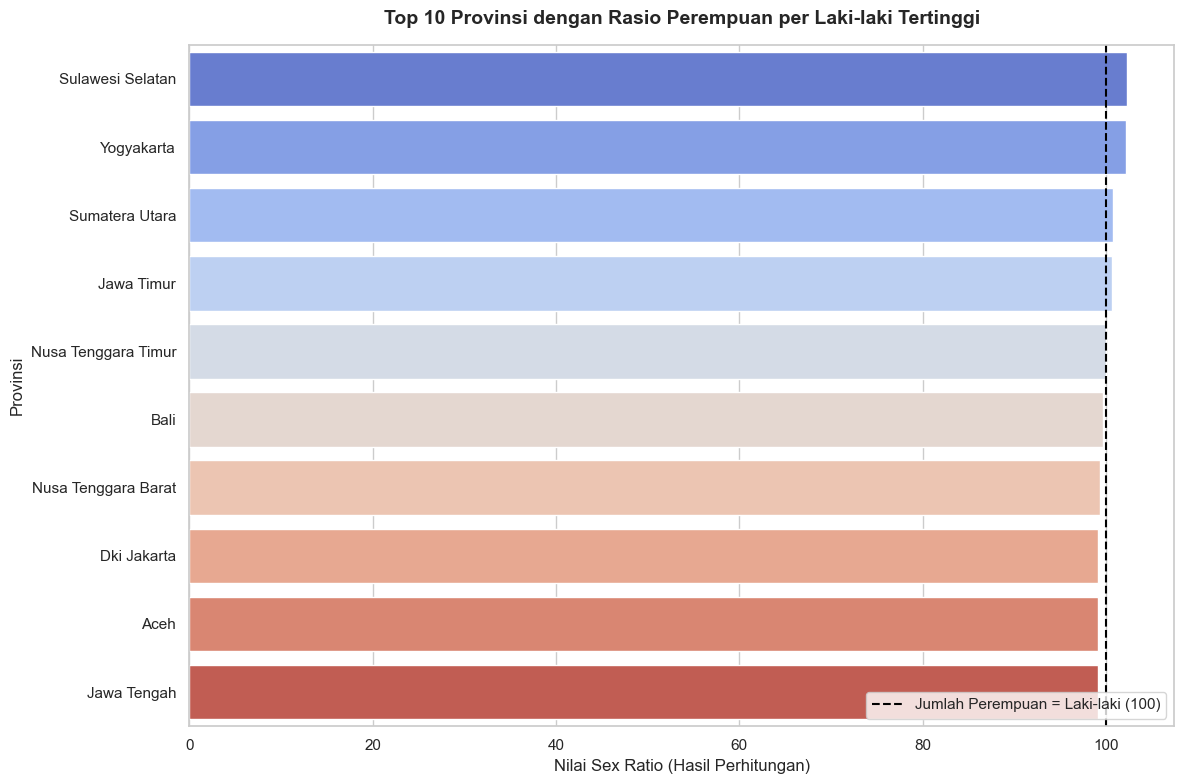

In [17]:
data_olah['Sex_ratio'] = (
    data_olah['perempuan']/
    data_olah['laki_laki']
)*100

df['persen_laki_laki']= (data_olah['laki_laki']/data_olah['total_keseluruhan'])*100
df['persen_perempuan']= (data_olah['perempuan']/data_olah['total_keseluruhan'])*100

display(data_olah)

data_sorted = data_olah.sort_values(by='Sex_ratio', ascending=False).head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.barplot(data=data_sorted, x='Sex_ratio', y='provinsi', palette='coolwarm')
plt.axvline(100, color='black', linestyle='--', linewidth=1.5, label='Jumlah Perempuan = Laki-laki (100)')

plt.title('Top 10 Provinsi dengan Rasio Perempuan per Laki-laki Tertinggi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Sex Ratio (Hasil Perhitungan)', fontsize=12)
plt.ylabel('Provinsi', fontsize=12)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

C:\Users\Adrian Alfarisi\AppData\Local\Temp\ipykernel_6328\149429653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_sorted2, x='Sex_ratio', y='provinsi', palette='coolwarm')


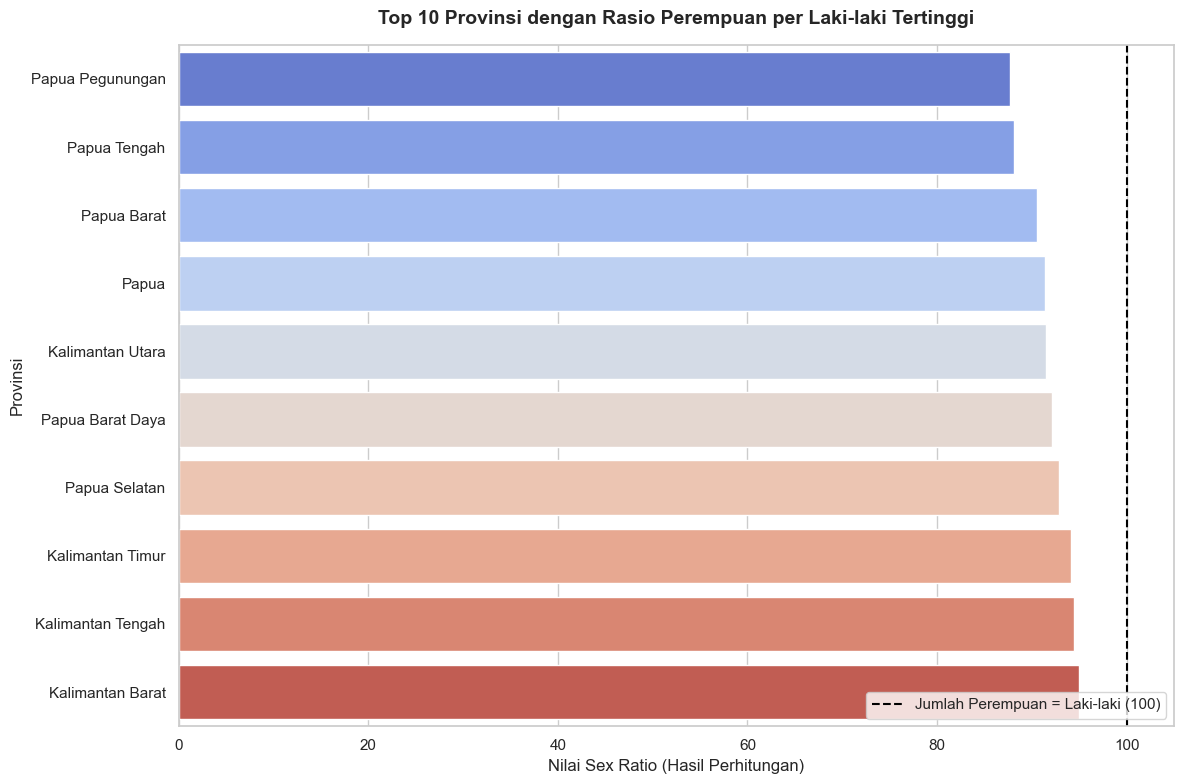

In [ ]:
data_sorted2 = data_olah.sort_values(by='Sex_ratio', ascending=True).head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.barplot(data=data_sorted2, x='Sex_ratio', y='provinsi', palette='coolwarm')
plt.axvline(100, color='black', linestyle='--', linewidth=1.5, label='Jumlah Perempuan = Laki-laki (100)')

plt.title('Top 10 Provinsi dengan Rasio Perempuan per Laki-laki Terendah', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Sex Ratio (Hasil Perhitungan)', fontsize=12)
plt.ylabel('Provinsi', fontsize=12)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Q1 : 1531750.0
Q3 : 6586943.5
IQR : 5055193.5
Batas Bawah : 0
Batas Atas : 14169733.75


,provinsi,laki_laki,perempuan,total_keseluruhan,Sex_ratio
8,Jawa Barat,25682100,25076900,50759000,97.643495
9,Jawa Tengah,19203434,19030499,38233933,99.099458
10,Jawa Timur,20978500,21110800,42089300,100.630646
36,Sumatera Utara,7862993,7922846,15785839,100.761199


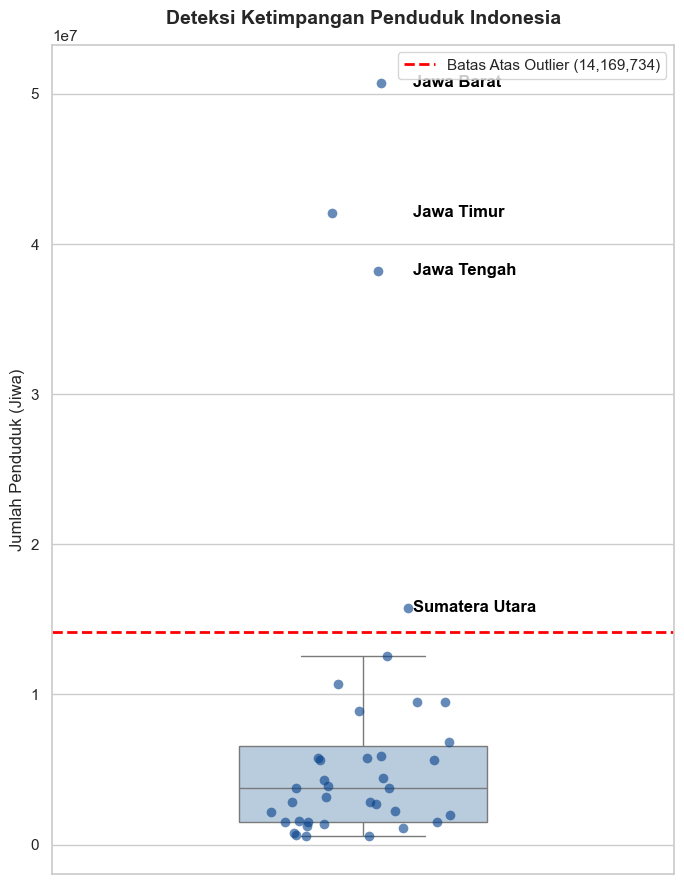

In [26]:
Q1 = data_olah['total_keseluruhan'].quantile(0.25)
Q3 = data_olah['total_keseluruhan'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - (1.5 * IQR)
batas_bawah = max(0, batas_bawah)
batas_atas = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Batas Bawah :", batas_bawah)
print("Batas Atas :", batas_atas)

outlier = data_olah[
    (data_olah['total_keseluruhan'] < batas_bawah) |
    (data_olah['total_keseluruhan'] > batas_atas)
]
display(outlier)


sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 9))
sns.boxplot(
    data=data_olah, 
    y='total_keseluruhan', 
    color='#b3cde3', 
    width=0.4, 
    fliersize=0, # Menyembunyikan fliers bawaan agar tidak tumpang tindih
    ax=ax
)

# Menambahkan Stripplot untuk melihat sebaran rill titik data provinsi
sns.stripplot(
    data=data_olah, 
    y='total_keseluruhan', 
    color='#023e8a', 
    alpha=0.6, 
    jitter=0.15, 
    size=7, 
    ax=ax
)

# Menambahkan garis horizontal penanda Batas Atas (Upper Bound) Outlier di grafik
ax.axhline(batas_atas, color='red', linestyle='--', linewidth=2, label=f'Batas Atas Outlier ({batas_atas:,.0f})')

# Menampilkan teks label nama untuk provinsi yang nilainya > upper_bound
for i in range(len(data_olah)):
    nilai_populasi = data_olah['total_keseluruhan'].iloc[i]
    if nilai_populasi > batas_atas:
        ax.text(
            x=0.08, 
            y=nilai_populasi, 
            s=data_olah['provinsi'].iloc[i], 
            color='black', 
            weight='bold',
            va='center'
        )

# Pengaturan komponen teks grafik
ax.set_title('Deteksi Ketimpangan Penduduk Indonesia', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Penduduk (Jiwa)', fontsize=12)
ax.legend(loc='upper right')
ax.set_xticklabels([])

plt.tight_layout()
plt.show()
